# Optimal Transport Basics — Visual Experiments

> **Goal:** Build intuition for Wasserstein distance, transport plans, and Sinkhorn regularization through small but exact visual examples.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Same mean, different geometry** | Why does OT detect a difference even when simple centroid-based summaries do not? |
| 2 | **Exact Kantorovich plan** | What does a transport plan actually look like for discrete histograms? |
| 3 | **Sinkhorn regularization** | How does the entropic parameter `epsilon` blur the transport plan and change the cost? |
| 4 | **Ground cost matters** | Why can the choice of metric change the OT answer completely? |

---
**Linked theory:** `../research/04-optimal-transport-basics.md`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import linprog
from scipy.spatial.distance import cdist

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})

In [2]:
def exact_ot(a, b, C):
    n, m = C.shape
    objective = C.ravel()
    A_eq = []
    b_eq = []

    for i in range(n):
        row = np.zeros(n * m)
        row[i * m:(i + 1) * m] = 1.0
        A_eq.append(row)
        b_eq.append(a[i])

    for j in range(m):
        col = np.zeros(n * m)
        col[j::m] = 1.0
        A_eq.append(col)
        b_eq.append(b[j])

    result = linprog(
        objective,
        A_eq=np.array(A_eq),
        b_eq=np.array(b_eq),
        bounds=(0, None),
        method='highs',
    )
    if not result.success:
        raise RuntimeError(result.message)
    plan = result.x.reshape(n, m)
    return plan, result.fun


def sinkhorn(a, b, C, epsilon=0.1, n_iters=400):
    K = np.exp(-C / epsilon)
    u = np.ones_like(a)
    v = np.ones_like(b)
    for _ in range(n_iters):
        u = a / (K @ v + 1e-12)
        v = b / (K.T @ u + 1e-12)
    plan = np.diag(u) @ K @ np.diag(v)
    cost = np.sum(plan * C)
    entropy = -np.sum(np.where(plan > 0, plan * np.log(plan), 0.0))
    return plan, cost, entropy


def draw_transport_lines(ax, source, target, plan, source_color='#1f77b4', target_color='#ff7f0e', threshold=0.03):
    ax.scatter(source[:, 0], source[:, 1], c=source_color, s=45, label='Source', zorder=3)
    ax.scatter(target[:, 0], target[:, 1], c=target_color, s=45, marker='s', label='Target', zorder=3)

    for i in range(plan.shape[0]):
        for j in range(plan.shape[1]):
            mass = plan[i, j]
            if mass < threshold:
                continue
            ax.plot(
                [source[i, 0], target[j, 0]],
                [source[i, 1], target[j, 1]],
                color='#6c757d',
                alpha=min(0.9, 0.15 + 2.5 * mass),
                linewidth=0.8 + 6.0 * mass,
                zorder=2,
            )
    ax.set_xlabel('x')
    ax.set_ylabel('y')


def whitening_matrix(points):
    centered = points - points.mean(axis=0, keepdims=True)
    covariance = np.cov(centered.T)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    eigenvalues = np.maximum(eigenvalues, 1e-8)
    return eigenvectors @ np.diag(1.0 / np.sqrt(eigenvalues)) @ eigenvectors.T

---
## Experiment 1: Same mean, different geometry

**Question:** Why can Wasserstein distance be large even when the centroids of two point clouds are identical?

This is the simplest argument for OT. Centroid-based summaries only care about first moments, while OT cares about how much mass must move through space.

In [3]:
np.random.seed(1)
source = np.array([
    [-2.4, -0.4], [-2.1, 0.2], [-1.8, -0.1], [-1.5, 0.4],
    [1.5, -0.4], [1.8, 0.2], [2.1, -0.1], [2.4, 0.4],
], dtype=float)
target = np.array([
    [-0.4, -2.4], [0.2, -2.1], [-0.1, -1.8], [0.4, -1.5],
    [-0.4, 1.5], [0.2, 1.8], [-0.1, 2.1], [0.4, 2.4],
], dtype=float)

weights_source = np.full(source.shape[0], 1.0 / source.shape[0])
weights_target = np.full(target.shape[0], 1.0 / target.shape[0])
C_same_mean = cdist(source, target, metric='euclidean')
plan_same_mean, ot_same_mean = exact_ot(weights_source, weights_target, C_same_mean)
mean_distance = np.linalg.norm(source.mean(axis=0) - target.mean(axis=0))

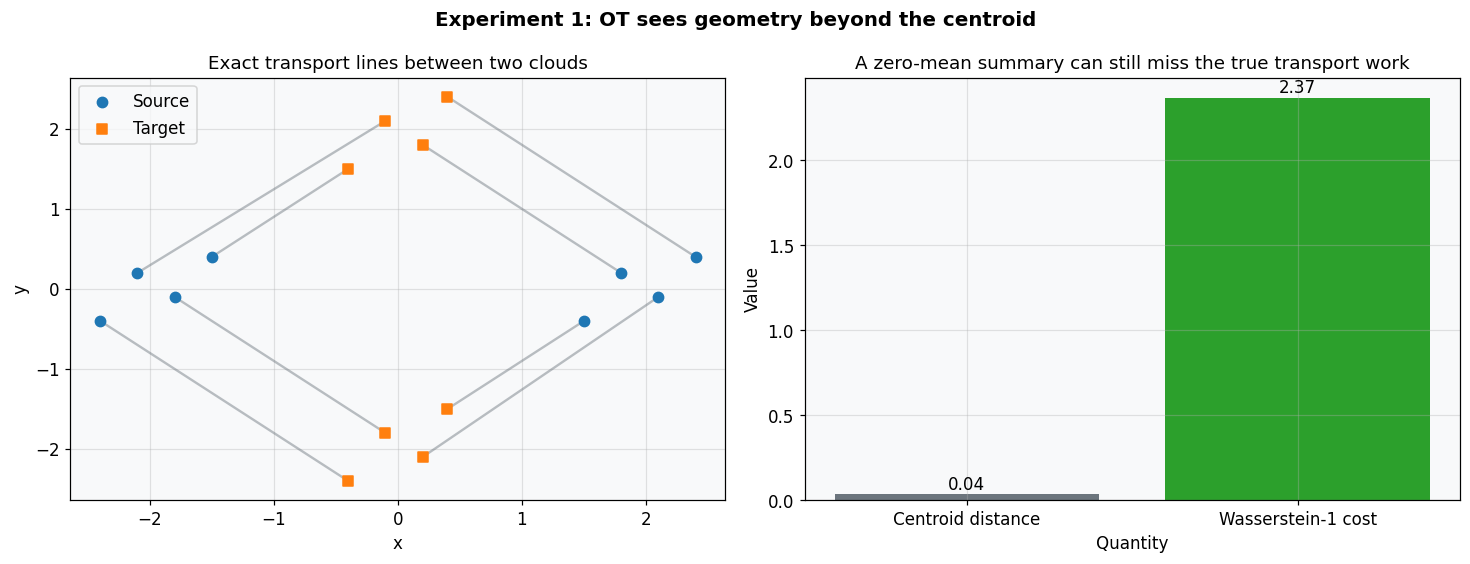

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
fig.suptitle('Experiment 1: OT sees geometry beyond the centroid', fontsize=13, fontweight='bold')

draw_transport_lines(axes[0], source, target, plan_same_mean, threshold=0.06)
axes[0].set_title('Exact transport lines between two clouds')
axes[0].legend(loc='upper left')

axes[1].bar(['Centroid distance', 'Wasserstein-1 cost'], [mean_distance, ot_same_mean], color=['#6c757d', '#2ca02c'])
axes[1].set_title('A zero-mean summary can still miss the true transport work')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Value')
for idx, value in enumerate([mean_distance, ot_same_mean]):
    axes[1].text(idx, value + 0.03, f'{value:.2f}', ha='center')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The two clouds share essentially the same centroid, so a mean-based comparison says they are almost identical. The transport lines and the Wasserstein bar tell a different story: mass must rotate and travel a substantial distance to turn one geometry into the other.
2. **Why it looks this way:** OT is not a moment-matching summary. It optimizes over all couplings and pays for actual movement in the ambient space.
3. **Key takeaway:** A low-dimensional summary such as the mean can hide major structural differences that OT still captures.

---
## Experiment 2: Exact Kantorovich plan on 1D histograms

**Question:** What does an optimal transport plan look like when we solve the discrete linear program exactly?

The Kantorovich relaxation replaces a hard point-to-point map by a matrix `P` that tells us how much mass moves from each source bin to each target bin.

In [5]:
np.random.seed(2)
a = np.array([0.40, 0.35, 0.25])
b = np.array([0.20, 0.50, 0.30])
x_positions = np.array([0.0, 1.0, 3.0])
y_positions = np.array([0.0, 2.0, 4.0])
C_hist = np.abs(x_positions[:, None] - y_positions[None, :])
exact_plan, exact_cost = exact_ot(a, b, C_hist)

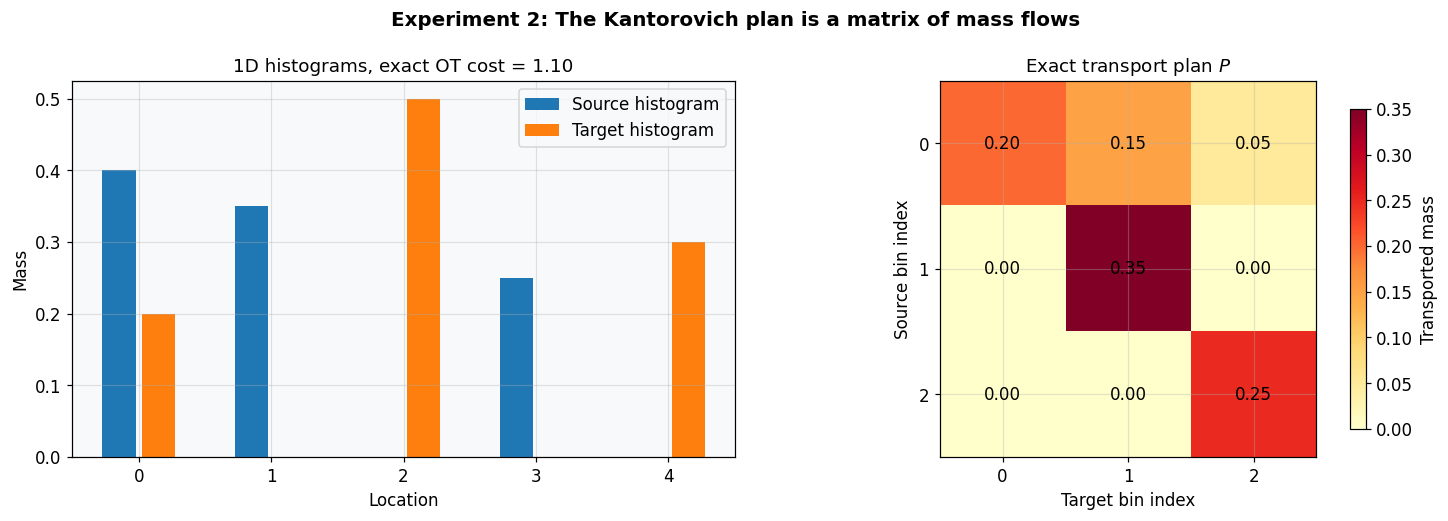

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
fig.suptitle('Experiment 2: The Kantorovich plan is a matrix of mass flows', fontsize=13, fontweight='bold')

axes[0].bar(x_positions - 0.15, a, width=0.25, color='#1f77b4', label='Source histogram')
axes[0].bar(y_positions + 0.15, b, width=0.25, color='#ff7f0e', label='Target histogram')
axes[0].set_title(f'1D histograms, exact OT cost = {exact_cost:.2f}')
axes[0].set_xlabel('Location')
axes[0].set_ylabel('Mass')
axes[0].legend(loc='upper right')

heatmap = axes[1].imshow(exact_plan, cmap='YlOrRd')
axes[1].set_title('Exact transport plan $P$')
axes[1].set_xlabel('Target bin index')
axes[1].set_ylabel('Source bin index')
axes[1].set_xticks(range(len(b)))
axes[1].set_yticks(range(len(a)))
for i in range(exact_plan.shape[0]):
    for j in range(exact_plan.shape[1]):
        axes[1].text(j, i, f'{exact_plan[i, j]:.2f}', ha='center', va='center', color='black')
fig.colorbar(heatmap, ax=axes[1], shrink=0.85, label='Transported mass')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The left panel defines two discrete distributions. The right panel shows the exact optimal plan: each cell tells how much source mass is sent to a target bin.
2. **Why it looks this way:** The linear program can split mass across several targets as long as row sums and column sums stay correct. That is precisely the Kantorovich relaxation.
3. **Key takeaway:** OT is not only a scalar distance; it also produces a structured correspondence matrix that can be inspected directly.

---
## Experiment 3: Sinkhorn regularization and the `epsilon` trade-off

**Question:** How does entropic regularization change the transport plan and the final transport cost?

Sinkhorn replaces the exact linear program with a smoother problem. The parameter `epsilon` controls how much smoothing we add.

In [7]:
np.random.seed(3)
epsilons = [0.05, 0.20, 0.80]
sinkhorn_results = []
for epsilon in epsilons:
    plan, cost, entropy = sinkhorn(a, b, C_hist, epsilon=epsilon, n_iters=500)
    sinkhorn_results.append((plan, cost, entropy))

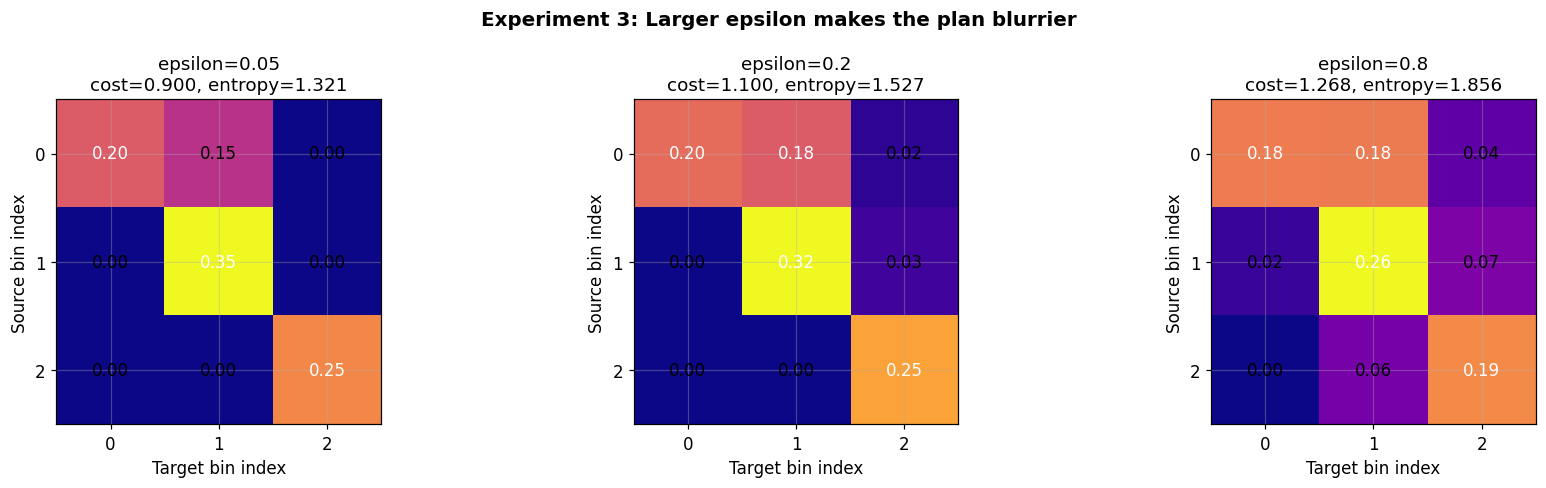

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('Experiment 3: Larger epsilon makes the plan blurrier', fontsize=13, fontweight='bold')

for ax, epsilon, (plan, cost, entropy) in zip(axes, epsilons, sinkhorn_results):
    heatmap = ax.imshow(plan, cmap='plasma')
    ax.set_title(f'epsilon={epsilon}\ncost={cost:.3f}, entropy={entropy:.3f}')
    ax.set_xlabel('Target bin index')
    ax.set_ylabel('Source bin index')
    ax.set_xticks(range(len(b)))
    ax.set_yticks(range(len(a)))
    for i in range(plan.shape[0]):
        for j in range(plan.shape[1]):
            ax.text(j, i, f'{plan[i, j]:.2f}', ha='center', va='center', color='white' if plan[i, j] > 0.15 else 'black')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** With a small `epsilon`, the Sinkhorn plan looks close to the sparse exact plan. As `epsilon` grows, the plan spreads mass over more cells and the transport cost drifts upward.
2. **Why it looks this way:** Entropic regularization rewards diffuse plans. The optimizer therefore trades some geometric sharpness for numerical smoothness and computational speed.
3. **Key takeaway:** Sinkhorn is powerful because it is fast and differentiable, but the regularization parameter directly controls a bias-variance style compromise.

---
## Experiment 4: Ground cost matters

**Question:** Why can changing the metric change the OT answer even when the source and target points stay the same?

Wasserstein distance is only as meaningful as the cost matrix we feed into it. In anisotropic spaces, Euclidean distance can overweight directions that are merely high-variance, not semantically important.

In [9]:
np.random.seed(4)
source_aniso = np.array([
    [-6.0, -0.4], [-5.2, 0.0], [-4.2, 0.3], [-3.3, -0.2],
    [3.3, 0.2], [4.2, -0.3], [5.2, 0.0], [6.0, 0.4],
], dtype=float)
target_aniso = np.array([
    [-5.5, 1.2], [-4.6, 1.5], [-3.8, 1.0], [-2.8, 1.4],
    [2.8, -1.4], [3.8, -1.0], [4.6, -1.5], [5.5, -1.2],
], dtype=float)

weights_uniform = np.full(source_aniso.shape[0], 1.0 / source_aniso.shape[0])
raw_cost = cdist(source_aniso, target_aniso, metric='euclidean')
raw_plan, raw_ot = exact_ot(weights_uniform, weights_uniform, raw_cost)

all_points = np.vstack([source_aniso, target_aniso])
W = whitening_matrix(all_points)
source_white = source_aniso @ W
_target_white = target_aniso @ W
white_cost = cdist(source_white, _target_white, metric='euclidean')
white_plan, white_ot = exact_ot(weights_uniform, weights_uniform, white_cost)

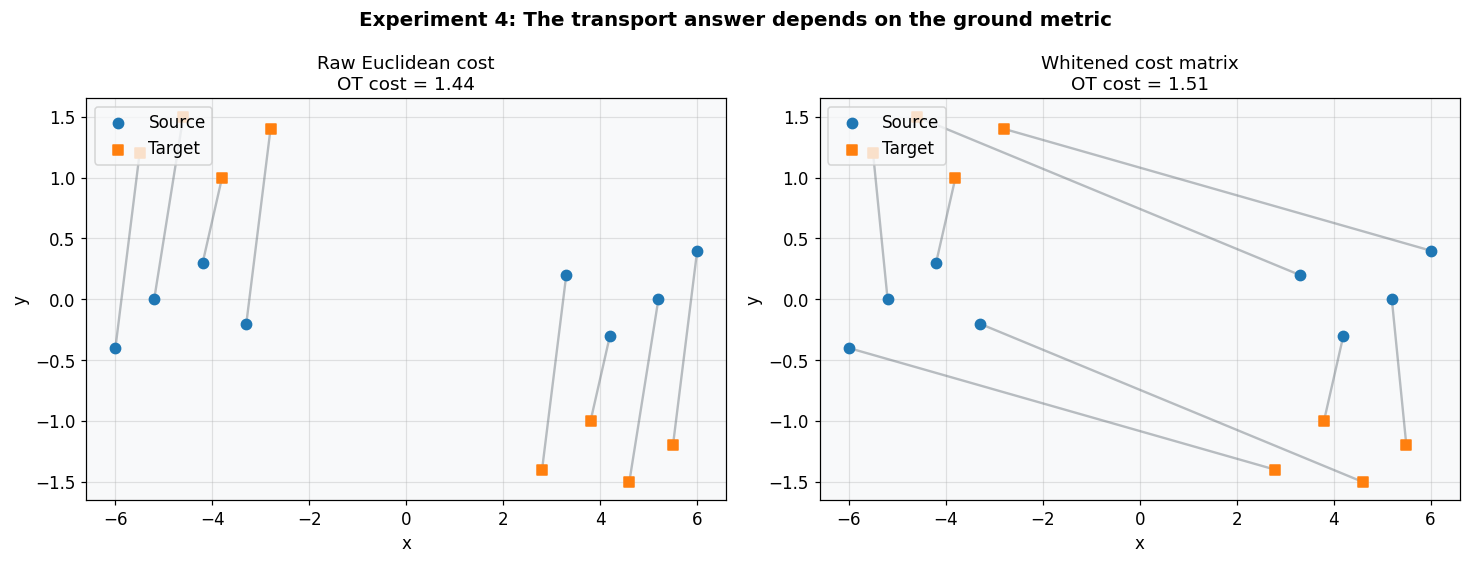

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
fig.suptitle('Experiment 4: The transport answer depends on the ground metric', fontsize=13, fontweight='bold')

draw_transport_lines(axes[0], source_aniso, target_aniso, raw_plan, threshold=0.06)
axes[0].set_title(f'Raw Euclidean cost\nOT cost = {raw_ot:.2f}')
axes[0].legend(loc='upper left')

draw_transport_lines(axes[1], source_aniso, target_aniso, white_plan, threshold=0.06)
axes[1].set_title(f'Whitened cost matrix\nOT cost = {white_ot:.2f}')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The same point clouds can yield different transport correspondences when we change only the cost matrix. In the whitened version, the high-variance horizontal direction matters less relative to the vertical shift.
2. **Why it looks this way:** Wasserstein distance is geometry-aware by design. That is a strength, but it also means the user must choose a geometry that matches the task.
3. **Key takeaway:** OT does not remove the need for metric design; it amplifies its importance.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Same mean, different geometry | OT captures spatial rearrangement that centroid summaries ignore. |
| 2. Exact Kantorovich plan | OT produces an inspectable matrix of mass flows, not just a distance. |
| 3. Sinkhorn regularization | Larger `epsilon` makes the plan smoother and more biased. |
| 4. Ground cost matters | The geometry encoded in the cost matrix directly shapes the OT answer. |

### Connection to the broader theory

These experiments cover the mathematical spine of the note: Monge motivates the problem, Kantorovich makes it flexible, Wasserstein turns it into a distance, and Sinkhorn makes it computationally practical. In Latent-Anything, the next step is to apply the same ideas to latent clouds and trajectory distributions.